# Urban Demand Forecasting — RQ3 
This standalone notebook implements **RQ3** from the thesis proposal: neighborhood semantic embeddings and spatial heterogeneity in shared-mobility demand forecasting.

The notebook auto-fetches the UCI Bike Sharing dataset, builds transparent proxy neighborhood semantics, trains the required baseline and neighborhood-aware models, and saves thesis-ready PDF figures plus CSV tables.

**Outputs generated:** 4 thesis-ready PDF figures, 3 cleaned CSV tables, and a final ZIP file in `/kaggle/working`.

**Important dataset note:** UCI Bike Sharing does not contain real station-level land-use/POI metadata. The notebook therefore uses clearly documented proxy neighborhood features. For a stronger final thesis, these proxies can be replaced with real station/zone-level metadata.


In [4]:
RQ = 'RQ3'

# ============================================================
# Common setup: auto-fetch dataset, preprocessing, metrics, models
# ============================================================
import os, glob, zipfile, urllib.request, warnings, shutil, math, json
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Thesis-ready plotting defaults: larger fonts, clean PDF export, readable axes.
plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})


from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

RQ = globals().get('RQ', 'RQ')
OUTPUT_DIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path.cwd()
OUTPUT_DIR = OUTPUT_DIR / f'urban_demand_{RQ}_outputs'
FIG_DIR = OUTPUT_DIR / 'figures_pdf'
TAB_DIR = OUTPUT_DIR / 'tables_csv'
for d in [OUTPUT_DIR, FIG_DIR, TAB_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Output directory:', OUTPUT_DIR)

def section(title):
    print('\n' + '='*90)
    print(title)
    print('='*90)

def save_table(df, name):
    path = TAB_DIR / f'{name}.csv'
    df.to_csv(path, index=False)
    print(f'Saved table: {path}')
    display(df.head(20))
    return path

def save_fig(name):
    path = FIG_DIR / f'{name}.pdf'
    plt.tight_layout()
    plt.savefig(path, format='pdf', bbox_inches='tight')
    print(f'Saved figure: {path}')
    plt.show()
    return path

def find_or_download_hour_csv():
    candidates = []
    search_roots = ['/kaggle/input', '/kaggle/working', str(Path.cwd()), '/mnt/data']
    for root in search_roots:
        if Path(root).exists():
            candidates.extend(glob.glob(os.path.join(root, '**', 'hour.csv'), recursive=True))
    if candidates:
        print('Found hour.csv:', candidates[0])
        return candidates[0]

    print('hour.csv not found. Downloading UCI Bike Sharing Dataset...')
    url = 'https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip'
    zip_path = OUTPUT_DIR / 'bike_sharing_dataset.zip'
    try:
        urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(OUTPUT_DIR / 'uci_bike_sharing')
        found = glob.glob(str(OUTPUT_DIR / 'uci_bike_sharing' / '**' / 'hour.csv'), recursive=True)
        if not found:
            raise FileNotFoundError('Downloaded zip did not contain hour.csv')
        print('Downloaded and extracted:', found[0])
        return found[0]
    except Exception as e:
        raise RuntimeError(
            'Could not fetch hour.csv automatically. On Kaggle, enable Internet in Notebook Settings, '
            'or add a dataset containing UCI Bike Sharing hour.csv. Original error: ' + str(e)
        )

def load_bike_data():
    hour_path = find_or_download_hour_csv()
    df = pd.read_csv(hour_path)
    df['dteday'] = pd.to_datetime(df['dteday'])
    df['datetime'] = df['dteday'] + pd.to_timedelta(df['hr'], unit='h')
    df = df.sort_values('datetime').reset_index(drop=True)
    print('Loaded shape:', df.shape)
    print('Date range:', df['datetime'].min(), 'to', df['datetime'].max())
    return df

def build_features(raw):
    df = raw.copy().sort_values('datetime').reset_index(drop=True)
    # Demand regimes aligned with the proposal: commute, leisure, weekend, holiday, severe weather, mixed.
    commute = (df['workingday'].eq(1)) & (df['hr'].isin([7,8,9,16,17,18,19]))
    leisure = (df['hr'].between(10,20)) & ((df['weekday'].isin([0,6])) | (df['holiday'].eq(1)))
    severe = df['weathersit'].ge(3)
    conditions = [severe, df['holiday'].eq(1), commute, leisure, df['weekday'].isin([0,6])]
    labels = ['Severe Weather', 'Holiday', 'Commute', 'Leisure', 'Weekend']
    df['regime'] = np.select(conditions, labels, default='Mixed Regime')

    # Transparent proxy neighborhood semantics because UCI has no station / POI metadata.
    # For a final thesis, replace this block with real station-level POI / land-use metadata.
    df['neighborhood_type'] = np.select(
        [commute & df['hr'].isin([7,8,9]), commute & df['hr'].isin([16,17,18,19]), leisure & df['season'].isin([2,3]), df['hr'].between(10,15) & df['workingday'].eq(1), severe],
        ['CBD', 'Residential', 'Tourist', 'University', 'Transit Hub'],
        default='Mixed-use'
    )
    # Pseudo-stations to enable cross-station and neighborhood experiments on UCI.
    df['station_id'] = (df['neighborhood_type'].astype('category').cat.codes * 10 + (df['hr'] // 4)).astype(int)
    df['station_id'] = 'S' + df['station_id'].astype(str).str.zfill(2)

    # Neighborhood feature proxies created from available temporal/weather indicators.
    nmap = {
        'CBD':          [0.20, 0.85, 0.95, 0.15, 0.25, 0.90],
        'Residential':  [0.90, 0.25, 0.30, 0.20, 0.15, 0.45],
        'University':   [0.35, 0.45, 0.30, 0.95, 0.30, 0.60],
        'Tourist':      [0.25, 0.55, 0.40, 0.25, 0.95, 0.65],
        'Transit Hub':  [0.35, 0.65, 0.55, 0.20, 0.35, 1.00],
        'Mixed-use':    [0.50, 0.55, 0.50, 0.45, 0.45, 0.65]
    }
    cols = ['residential_density','commercial_density','office_intensity','education_density','tourism_poi_density','transit_access']
    for j,c in enumerate(cols):
        df[c] = df['neighborhood_type'].map(lambda x: nmap[x][j]).astype(float)

    # Time encodings
    df['hr_sin'] = np.sin(2*np.pi*df['hr']/24)
    df['hr_cos'] = np.cos(2*np.pi*df['hr']/24)
    df['weekday_sin'] = np.sin(2*np.pi*df['weekday']/7)
    df['weekday_cos'] = np.cos(2*np.pi*df['weekday']/7)
    df['month'] = df['datetime'].dt.month
    df['month_sin'] = np.sin(2*np.pi*df['month']/12)
    df['month_cos'] = np.cos(2*np.pi*df['month']/12)
    df['is_commute'] = commute.astype(int)
    df['is_weekend'] = df['weekday'].isin([0,6]).astype(int)

    for lag in [1,2,3,6,12,24,48,168]:
        df[f'lag_{lag}'] = df['cnt'].shift(lag)
    for win in [3,6,24,168]:
        df[f'roll_mean_{win}'] = df['cnt'].shift(1).rolling(win).mean()
        df[f'roll_std_{win}'] = df['cnt'].shift(1).rolling(win).std()
    df['diff_1'] = df['cnt'].diff(1).shift(1)
    df['diff_24'] = df['cnt'].diff(24).shift(1)
    df = df.dropna().reset_index(drop=True)
    return df

RAW_DF = load_bike_data()
DATA = build_features(RAW_DF)
print('Feature-ready shape:', DATA.shape)

TARGET = 'cnt'
base_temporal = ['hr','hr_sin','hr_cos','weekday','weekday_sin','weekday_cos','month_sin','month_cos', 'season', 'yr']
weather_features = ['temp','atemp','hum','windspeed','weathersit']
calendar_features = ['holiday','workingday','is_weekend','is_commute']
lag_features = [c for c in DATA.columns if c.startswith('lag_') or c.startswith('roll_') or c.startswith('diff_')]
neighborhood_features = ['residential_density','commercial_density','office_intensity','education_density','tourism_poi_density','transit_access']
cat_features = ['neighborhood_type','regime']

FEATURE_SETS = {
    'Historical Average': [],
    'Temporal Only': base_temporal + lag_features,
    'Temporal + Weather': base_temporal + lag_features + weather_features,
    'Temporal + Calendar': base_temporal + lag_features + calendar_features,
    'Temporal + Neighborhood': base_temporal + lag_features + neighborhood_features + ['neighborhood_type'],
    'Weather + Calendar': base_temporal + lag_features + weather_features + calendar_features,
    'Full Cross-Modal Fusion': base_temporal + lag_features + weather_features + calendar_features + neighborhood_features + ['neighborhood_type']
}

def time_split(df, train_frac=0.70, val_frac=0.15):
    n = len(df)
    train_end = int(n*train_frac)
    val_end = int(n*(train_frac+val_frac))
    return df.iloc[:train_end].copy(), df.iloc[train_end:val_end].copy(), df.iloc[val_end:].copy()

TRAIN, VAL, TEST = time_split(DATA)
print('Train/Val/Test:', TRAIN.shape, VAL.shape, TEST.shape)


def make_preprocessor(features):
    numeric = [f for f in features if f not in ['neighborhood_type','regime','station_id']]
    categorical = [f for f in features if f in ['neighborhood_type','regime','station_id']]
    transformers = []
    if numeric:
        transformers.append(('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), numeric))
    if categorical:
        transformers.append(('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical))
    return ColumnTransformer(transformers, remainder='drop')


def build_model(model_name='rf', features=None):
    if features is None:
        features = FEATURE_SETS['Full Cross-Modal Fusion']
    if model_name == 'ridge':
        reg = Ridge(alpha=2.0)
    elif model_name == 'gbr':
        reg = GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=160, learning_rate=0.05, max_depth=3)
    elif model_name == 'extra':
        reg = ExtraTreesRegressor(random_state=RANDOM_STATE, n_estimators=160, max_depth=14, min_samples_leaf=2, n_jobs=-1)
    elif model_name == 'xgb' and HAS_XGB:
        reg = XGBRegressor(random_state=RANDOM_STATE, n_estimators=220, max_depth=4, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, objective='reg:squarederror', n_jobs=-1)
    else:
        reg = RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=160, max_depth=14, min_samples_leaf=2, n_jobs=-1)
    return Pipeline([('prep', make_preprocessor(features)), ('model', reg)])


def metrics(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    denom = np.sum(np.abs(y_true)) + 1e-9
    wape = float(np.sum(np.abs(y_true-y_pred))/denom*100)
    peak_threshold = np.quantile(y_true, 0.90)
    mask = y_true >= peak_threshold
    peak_mae = float(mean_absolute_error(y_true[mask], y_pred[mask])) if mask.any() else np.nan
    return {'RMSE':rmse, 'MAE':mae, 'WAPE (%)':wape, 'Peak-MAE':peak_mae}


def historical_average_predict(train_df, test_df, group_cols=['hr','weekday']):
    avg = train_df.groupby(group_cols)[TARGET].mean().reset_index().rename(columns={TARGET:'pred'})
    tmp = test_df[group_cols].merge(avg, on=group_cols, how='left')['pred']
    fallback = train_df[TARGET].mean()
    return tmp.fillna(fallback).values


def fit_predict_variant(name, train_df=TRAIN, test_df=TEST, model_name='rf'):
    if name == 'Historical Average':
        pred = historical_average_predict(train_df, test_df)
        return None, pred
    feats = FEATURE_SETS[name]
    pipe = build_model(model_name=model_name, features=feats)
    pipe.fit(train_df[feats], train_df[TARGET])
    pred = pipe.predict(test_df[feats])
    pred = np.clip(pred, 0, None)
    return pipe, pred


def evaluate_variants(variants=None, model_name='rf', train_df=TRAIN, test_df=TEST):
    if variants is None:
        variants = list(FEATURE_SETS.keys())
    rows = []
    preds = {}
    models = {}
    for name in variants:
        model, pred = fit_predict_variant(name, train_df=train_df, test_df=test_df, model_name=model_name)
        row = {'Model': name, **metrics(test_df[TARGET], pred)}
        rows.append(row); preds[name]=pred; models[name]=model
    perf = pd.DataFrame(rows).sort_values('RMSE')
    return perf, preds, models


def zip_outputs(zip_name=None):
    if zip_name is None:
        zip_name = f'urban_demand_{RQ}_outputs.zip'
    zip_path = OUTPUT_DIR.parent / zip_name
    if zip_path.exists():
        zip_path.unlink()
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as z:
        for p in OUTPUT_DIR.rglob('*'):
            if p.is_file():
                z.write(p, p.relative_to(OUTPUT_DIR.parent))
    print('Final ZIP created:', zip_path)
    return zip_path


Output directory: /kaggle/working/urban_demand_RQ3_outputs
Found hour.csv: /kaggle/working/urban_demand_RQ3_outputs/uci_bike_sharing/hour.csv
Loaded shape: (17379, 18)
Date range: 2011-01-01 00:00:00 to 2012-12-31 23:00:00
Feature-ready shape: (17211, 54)
Train/Val/Test: (12047, 54) (2582, 54) (2582, 54)



RQ3 — Neighborhood semantic embeddings and spatial heterogeneity
Note: The UCI Bike Sharing dataset does not contain true station-level land-use or POI metadata. Therefore, this notebook constructs transparent proxy neighborhood semantics from available temporal, weather, and demand-context variables. For a final real-world thesis extension, replace the proxy block in build_features() with real station/zone land-use, POI, census, or transit data.
Saved table: /kaggle/working/urban_demand_RQ3_outputs/tables_csv/RQ3_Table_1_neighborhood_embedding_dataset_thesis_ready.csv


,Station ID,Neighborhood Type,Sample Count,Residential,Commercial,Office,Education,Tourism POI,Transit Access,Average Demand,Avg AM Peak Demand,Weekend Uplift (%),AM Peak Availability,Weekend Uplift Availability,Embedding Dimension 1,Embedding Dimension 2,Cluster Label
0,S01,CBD,491,0.20,0.85,0.95,0.15,0.25,0.90,292.7067,292.7067,Insufficient samples,Available,Insufficient samples,4.2490,0.9382,C1
1,S02,CBD,982,0.20,0.85,0.95,0.15,0.25,0.90,361.3768,361.3768,Insufficient samples,Available,Insufficient samples,4.5399,1.5661,C1
2,S10,Mixed-use,2620,0.50,0.55,0.50,0.45,0.45,0.65,32.0328,Insufficient samples,250.3551,Insufficient samples,Available,-0.8219,-1.5033,C0
3,S11,Mixed-use,2171,0.50,0.55,0.50,0.45,0.45,0.65,36.5233,45.5446,-57.5749,Available,Available,-1.0593,-1.0537,C0
4,S12,Mixed-use,655,0.50,0.55,0.50,0.45,0.45,0.65,174.4992,143.9608,2.6278,Available,Available,-0.6656,-0.0849,C0
5,S13,Mixed-use,443,0.50,0.55,0.50,0.45,0.45,0.65,317.6005,Insufficient samples,47.9342,Insufficient samples,Available,-0.9173,0.3715,C0
6,S14,Mixed-use,425,0.50,0.55,0.50,0.45,0.45,0.65,239.4847,Insufficient samples,23.6964,Insufficient samples,Available,-0.8822,0.0309,C0
7,S15,Mixed-use,2539,0.50,0.55,0.50,0.45,0.45,0.65,158.5238,Insufficient samples,-29.6557,Insufficient samples,Available,-0.8426,-0.2611,C0
8,S24,Residential,1974,0.90,0.25,0.30,0.20,0.15,0.45,417.5922,Insufficient samples,Insufficient samples,Insufficient samples,Insufficient samples,-3.6227,0.2331,C4
9,S32,Tourist,226,0.25,0.55,0.40,0.25,0.95,0.65,350.0752,Insufficient samples,10.7155,Insufficient samples,Available,-0.6265,2.1481,C2


Saved table: /kaggle/working/urban_demand_RQ3_outputs/tables_csv/RQ3_Table_2_performance_by_neighborhood_type_thesis_ready.csv


,Neighborhood Type,Model,Test Samples,RMSE,MAE,WAPE (%),Peak-MAE,RMSE Reduction from Neighborhood (%),RMSE Reduction from Full Fusion (%),Best Model by RMSE
0,CBD,Temporal Only,213,104.2470,77.3708,17.5205,159.2990,-0.2866,1.4713,Full Cross-Modal Fusion
1,CBD,Temporal + Neighborhood,213,104.5458,78.0145,17.6663,163.2428,-0.2866,1.4713,Full Cross-Modal Fusion
2,CBD,Full Cross-Modal Fusion,213,102.7132,77.3029,17.5051,159.7034,-0.2866,1.4713,Full Cross-Modal Fusion
3,Mixed-use,Temporal Only,1507,37.5084,22.6969,14.8214,59.8996,0.4293,1.8226,Full Cross-Modal Fusion
4,Mixed-use,Temporal + Neighborhood,1507,37.3473,22.4298,14.6470,60.7640,0.4293,1.8226,Full Cross-Modal Fusion
5,Mixed-use,Full Cross-Modal Fusion,1507,36.8247,22.1830,14.4858,59.3857,0.4293,1.8226,Full Cross-Modal Fusion
6,Residential,Temporal Only,290,106.6628,76.8125,15.0735,206.3019,1.2129,5.6504,Full Cross-Modal Fusion
7,Residential,Temporal + Neighborhood,290,105.3691,76.1775,14.9489,204.7518,1.2129,5.6504,Full Cross-Modal Fusion
8,Residential,Full Cross-Modal Fusion,290,100.6359,72.7365,14.2736,178.7709,1.2129,5.6504,Full Cross-Modal Fusion
9,Tourist,Temporal Only,33,74.7922,61.2391,10.4699,127.1718,0.3087,7.6834,Full Cross-Modal Fusion


Saved table: /kaggle/working/urban_demand_RQ3_outputs/tables_csv/RQ3_Table_3_neighborhood_cluster_profiles_thesis_ready.csv


,Cluster Label,Dominant Function,No. of Proxy Stations,Sample Count,Residential,Commercial,Office,Education,Tourism POI,Transit Access,Average Demand,Avg AM Peak Demand,Weekend Uplift (%),Thesis Interpretation
0,C0,Mixed-use,8,11806,0.4625,0.525,0.45,0.575,0.4125,0.6375,162.9674,94.7527,39.5638,Dominant Mixed-use cluster with strongest tran...
1,C1,CBD,2,1473,0.2000,0.850,0.95,0.150,0.2500,0.9000,327.0418,327.0418,Insufficient samples,Dominant CBD cluster with strongest office signal
2,C2,Tourist,4,1240,0.2500,0.550,0.40,0.250,0.9500,0.6500,346.4007,Insufficient samples,0.5378,Dominant Tourist cluster with strongest touris...
3,C3,Transit Hub,6,718,0.3500,0.650,0.55,0.200,0.3500,1.0000,74.6410,41.7708,12.5991,Dominant Transit Hub cluster with strongest tr...
4,C4,Residential,1,1974,0.9000,0.250,0.30,0.200,0.1500,0.4500,417.5922,Insufficient samples,Insufficient samples,Dominant Residential cluster with strongest re...


Saved figure: /kaggle/working/urban_demand_RQ3_outputs/figures_pdf/RQ3_Figure_1_neighborhood_embedding_space_thesis_ready.pdf


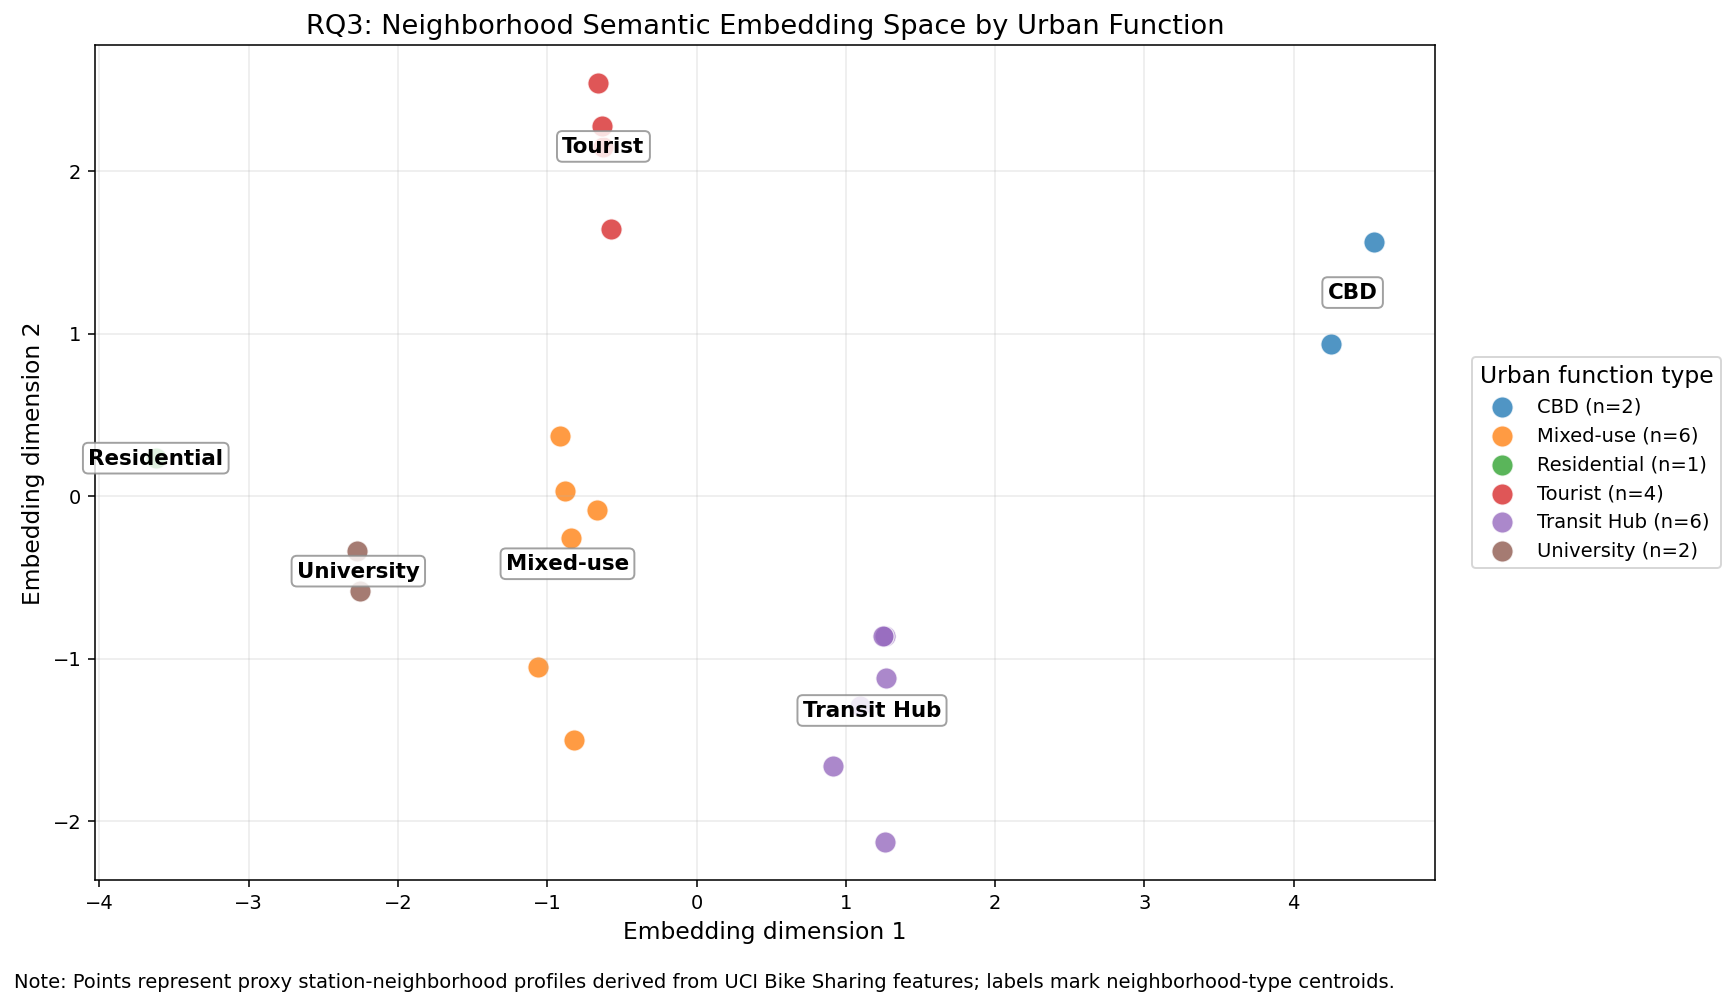

Saved figure: /kaggle/working/urban_demand_RQ3_outputs/figures_pdf/RQ3_Figure_2_spatial_error_reduction_thesis_ready.pdf


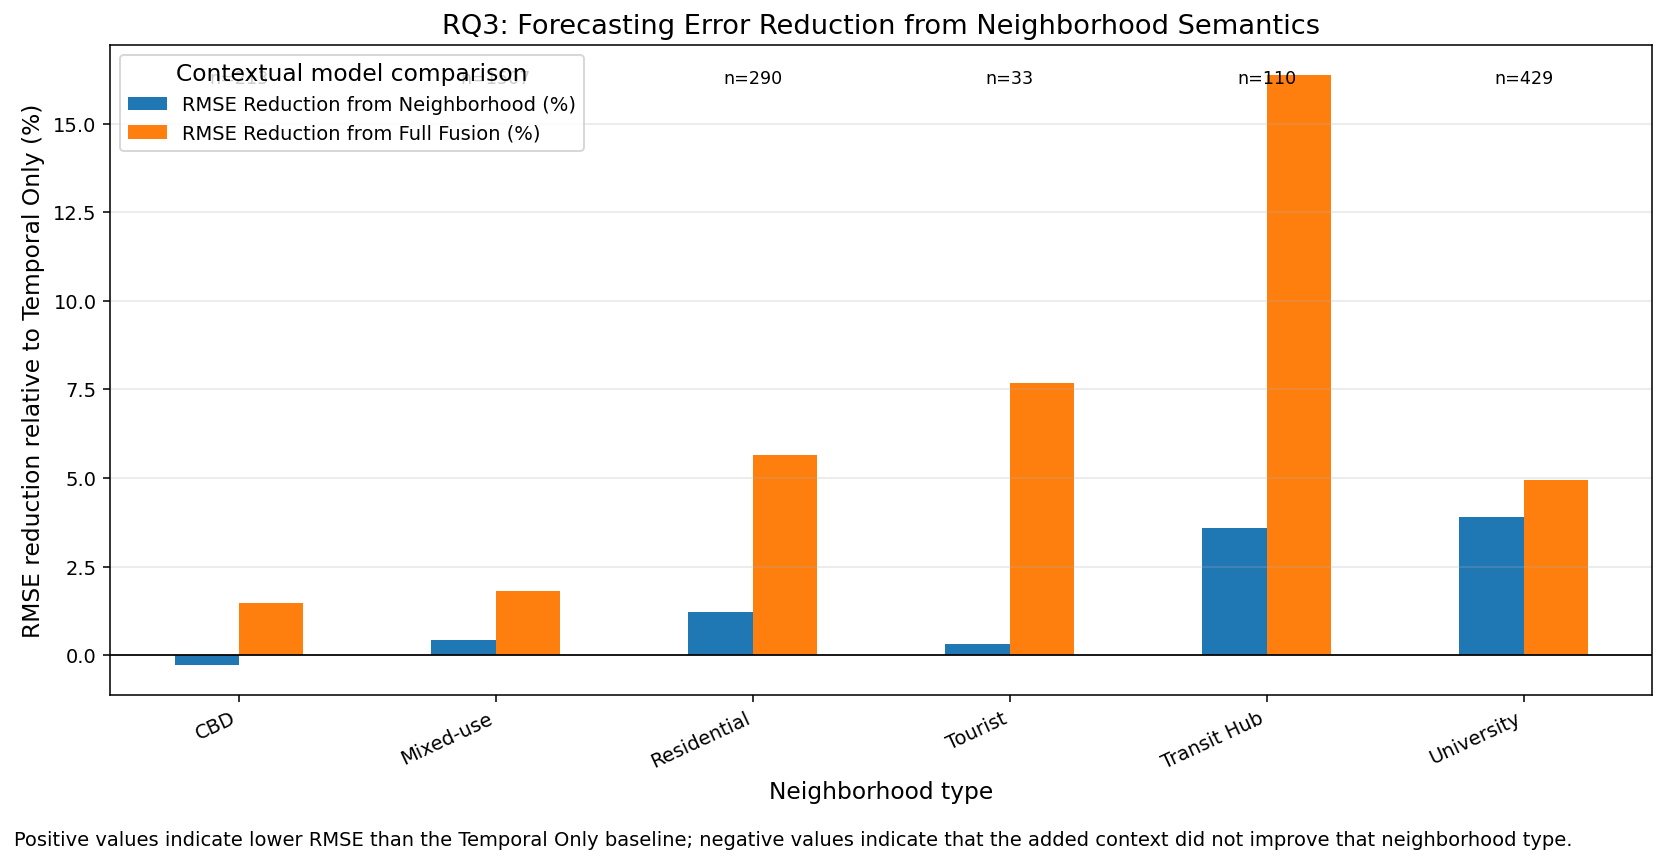

Saved figure: /kaggle/working/urban_demand_RQ3_outputs/figures_pdf/RQ3_Figure_3_cluster_profile_heatmap_thesis_ready.pdf


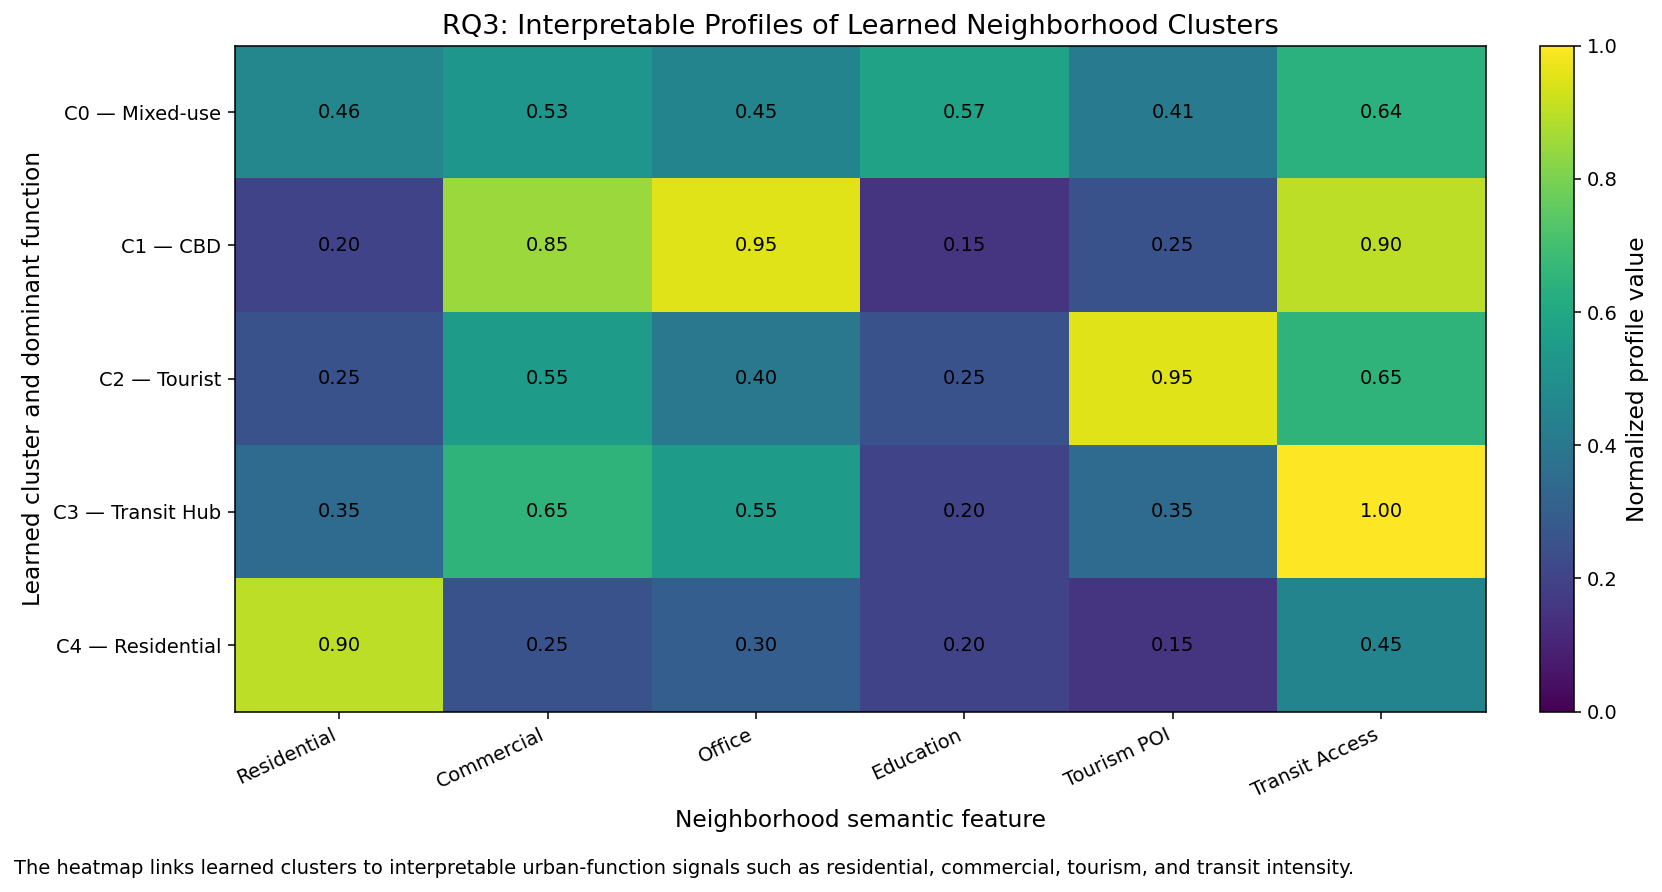

Saved figure: /kaggle/working/urban_demand_RQ3_outputs/figures_pdf/RQ3_Figure_4_hourly_demand_signatures_thesis_ready.pdf


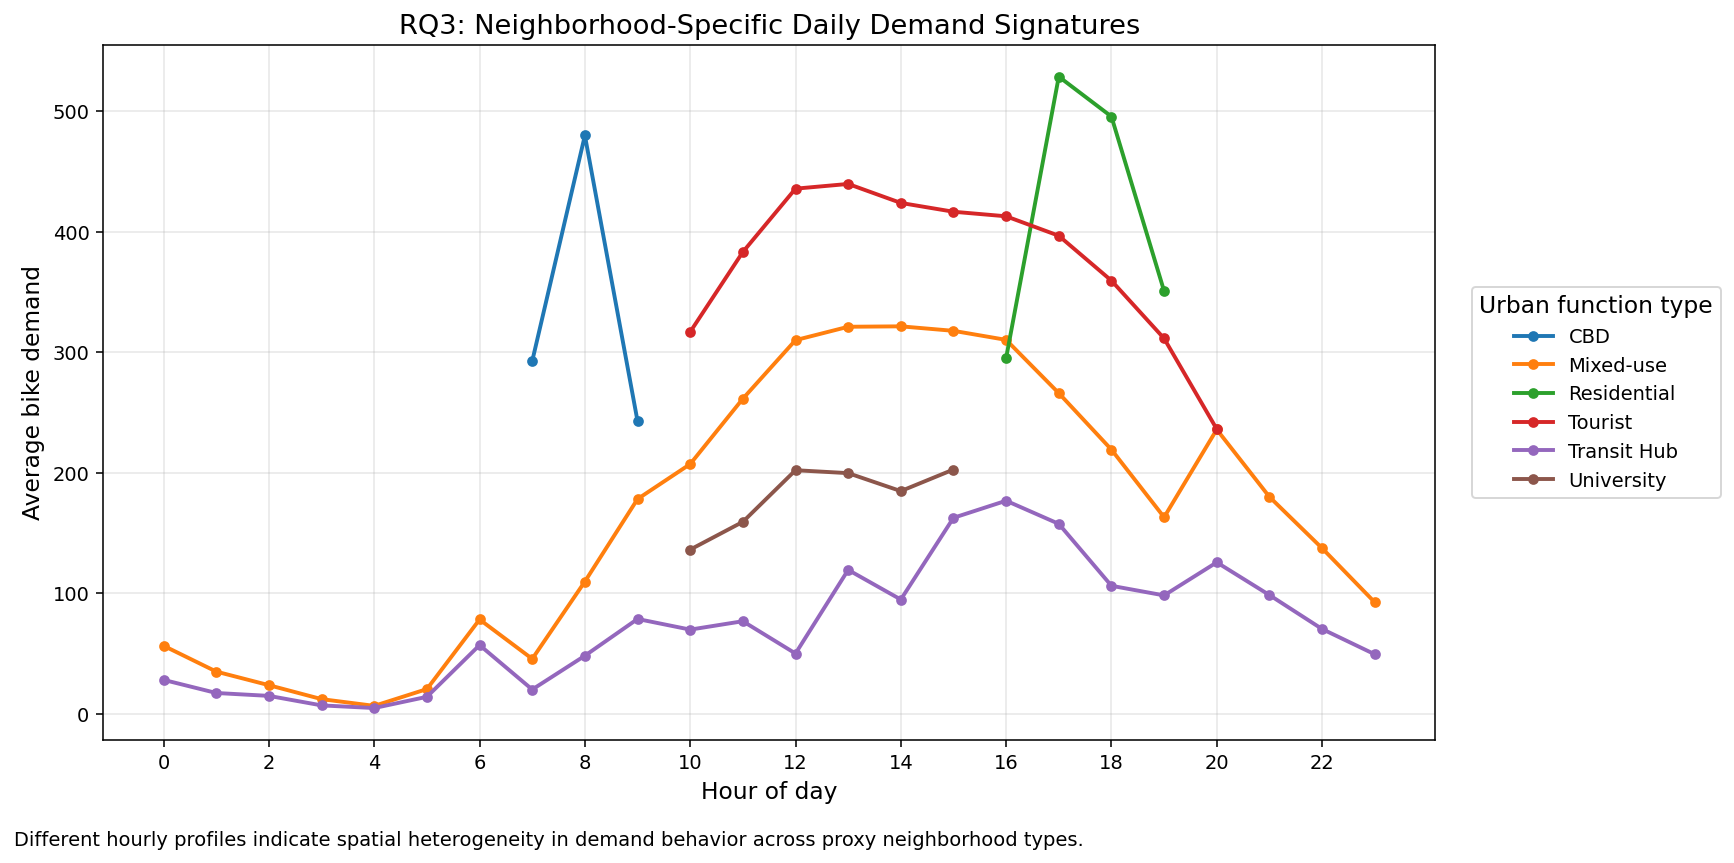

PosixPath('/kaggle/working/urban_demand_RQ3_outputs/figures_pdf/RQ3_Figure_4_hourly_demand_signatures_thesis_ready.pdf')

In [5]:
# ============================================================
# RQ3: Neighborhood semantic embeddings and spatial heterogeneity
# Thesis-ready version: readable figures, cleaned tables, clear proxy-data notes.
# Produces 4 PDF figures + 3 CSV tables.
# ============================================================
section('RQ3 — Neighborhood semantic embeddings and spatial heterogeneity')

# ------------------------------------------------------------------
# Methodological note
# ------------------------------------------------------------------
print(
    "Note: The UCI Bike Sharing dataset does not contain true station-level land-use or POI metadata. "
    "Therefore, this notebook constructs transparent proxy neighborhood semantics from available "
    "temporal, weather, and demand-context variables. For a final real-world thesis extension, replace "
    "the proxy block in build_features() with real station/zone land-use, POI, census, or transit data."
)

variants = ['Temporal Only', 'Temporal + Neighborhood', 'Full Cross-Modal Fusion']
perf, preds, models = evaluate_variants(variants=variants, model_name='rf')

# ------------------------------------------------------------------
# Helper functions for clean thesis tables
# ------------------------------------------------------------------
def safe_mean(series):
    series = pd.Series(series).dropna()
    return float(series.mean()) if len(series) else np.nan

def safe_weekend_uplift(group):
    weekend = group.loc[group['is_weekend'].eq(1), 'cnt']
    weekday = group.loc[group['is_weekend'].eq(0), 'cnt']
    if len(weekend) == 0 or len(weekday) == 0 or weekday.mean() == 0:
        return np.nan
    return float((weekend.mean() - weekday.mean()) / weekday.mean() * 100)

def table_display_ready(df):
    """Keep numeric values for analysis but replace missing table outputs for thesis readability."""
    out = df.copy()
    for col in out.select_dtypes(include=[np.number]).columns:
        out[col] = out[col].round(4)
    return out.replace({np.nan: 'Insufficient samples'})

# Shorter feature labels for figures and tables
feature_label_map = {
    'residential_density': 'Residential',
    'commercial_density': 'Commercial',
    'office_intensity': 'Office',
    'education_density': 'Education',
    'tourism_poi_density': 'Tourism POI',
    'transit_access': 'Transit Access'
}
short_feature_names = [feature_label_map[c] for c in neighborhood_features]

# ------------------------------------------------------------------
# Construct neighborhood profile / embedding table
# ------------------------------------------------------------------
profile_cols = neighborhood_features + ['cnt']
profiles = DATA.groupby(['station_id', 'neighborhood_type'])[profile_cols].mean().reset_index()

am_peak = DATA[DATA['hr'].isin([7, 8, 9])].groupby('station_id')['cnt'].mean()
weekend_uplift = DATA.groupby('station_id').apply(safe_weekend_uplift)
sample_count = DATA.groupby('station_id')['cnt'].size()

profiles['Sample Count'] = profiles['station_id'].map(sample_count).astype(int)
profiles['Avg AM Peak Demand'] = profiles['station_id'].map(am_peak)
profiles['Weekend Uplift (%)'] = profiles['station_id'].map(weekend_uplift)
profiles['AM Peak Availability'] = np.where(profiles['Avg AM Peak Demand'].isna(), 'Insufficient samples', 'Available')
profiles['Weekend Uplift Availability'] = np.where(profiles['Weekend Uplift (%)'].isna(), 'Insufficient samples', 'Available')

# Fill missing values only for embedding computation, not for the raw thesis table.
embedding_features = neighborhood_features + ['cnt', 'Avg AM Peak Demand', 'Weekend Uplift (%)']
Xemb_df = profiles[embedding_features].copy()
for col in Xemb_df.columns:
    Xemb_df[col] = Xemb_df[col].fillna(Xemb_df[col].median())

scaled_embedding_input = StandardScaler().fit_transform(Xemb_df.values)
emb = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(scaled_embedding_input)
profiles['Embedding Dimension 1'] = emb[:, 0]
profiles['Embedding Dimension 2'] = emb[:, 1]
profiles['Cluster'] = KMeans(
    n_clusters=min(5, len(profiles)), random_state=RANDOM_STATE, n_init=10
).fit_predict(scaled_embedding_input)
profiles['Cluster Label'] = 'C' + profiles['Cluster'].astype(str)

# Make Table 1 readable and thesis-friendly.
table1_cols = [
    'station_id', 'neighborhood_type', 'Sample Count',
    *neighborhood_features,
    'cnt', 'Avg AM Peak Demand', 'Weekend Uplift (%)',
    'AM Peak Availability', 'Weekend Uplift Availability',
    'Embedding Dimension 1', 'Embedding Dimension 2', 'Cluster Label'
]
table1 = profiles[table1_cols].rename(columns={
    'station_id': 'Station ID',
    'neighborhood_type': 'Neighborhood Type',
    'cnt': 'Average Demand',
    **feature_label_map
})
save_table(table_display_ready(table1), 'RQ3_Table_1_neighborhood_embedding_dataset_thesis_ready')

# ------------------------------------------------------------------
# Table 2: forecasting performance by neighborhood type
# ------------------------------------------------------------------
rows = []
for ntype in sorted(TEST['neighborhood_type'].unique()):
    mask = TEST['neighborhood_type'].eq(ntype).values
    n_obs = int(mask.sum())
    for name, pred in preds.items():
        mm = metrics(TEST.loc[mask, TARGET], pred[mask])
        rows.append({'Neighborhood Type': ntype, 'Model': name, 'Test Samples': n_obs, **mm})
nt_perf = pd.DataFrame(rows)

wide = nt_perf.pivot(index='Neighborhood Type', columns='Model', values='RMSE')
wide['RMSE Reduction from Neighborhood (%)'] = (
    (wide['Temporal Only'] - wide['Temporal + Neighborhood']) / wide['Temporal Only'] * 100
)
wide['RMSE Reduction from Full Fusion (%)'] = (
    (wide['Temporal Only'] - wide['Full Cross-Modal Fusion']) / wide['Temporal Only'] * 100
)
wide['Best Model by RMSE'] = wide[variants].idxmin(axis=1)
wide['Best RMSE'] = wide[variants].min(axis=1)
wide = wide.reset_index()

nt_perf_enriched = nt_perf.merge(
    wide[['Neighborhood Type', 'RMSE Reduction from Neighborhood (%)', 'RMSE Reduction from Full Fusion (%)', 'Best Model by RMSE']],
    on='Neighborhood Type', how='left'
)
save_table(table_display_ready(nt_perf_enriched), 'RQ3_Table_2_performance_by_neighborhood_type_thesis_ready')

# ------------------------------------------------------------------
# Table 3: interpretable neighborhood cluster profiles
# ------------------------------------------------------------------
cluster_profiles = profiles.groupby('Cluster')[neighborhood_features + ['cnt', 'Avg AM Peak Demand', 'Weekend Uplift (%)', 'Sample Count']].agg({
    **{c: 'mean' for c in neighborhood_features},
    'cnt': 'mean',
    'Avg AM Peak Demand': 'mean',
    'Weekend Uplift (%)': 'mean',
    'Sample Count': 'sum'
}).reset_index()
cluster_profiles['Cluster Label'] = 'C' + cluster_profiles['Cluster'].astype(str)
cluster_profiles['Dominant Function'] = profiles.groupby('Cluster')['neighborhood_type'].agg(lambda x: x.value_counts().idxmax()).values
cluster_profiles['No. of Proxy Stations'] = profiles.groupby('Cluster')['station_id'].count().values

# Add short thesis interpretation per cluster based on dominant feature.
def cluster_interpretation(row):
    vals = {feature_label_map[c]: row[c] for c in neighborhood_features}
    strongest = max(vals, key=vals.get)
    return f"Dominant {row['Dominant Function']} cluster with strongest {strongest.lower()} signal"

cluster_profiles['Thesis Interpretation'] = cluster_profiles.apply(cluster_interpretation, axis=1)
cluster_table = cluster_profiles.rename(columns={
    'cnt': 'Average Demand',
    **feature_label_map
})[
    ['Cluster Label', 'Dominant Function', 'No. of Proxy Stations', 'Sample Count',
     *short_feature_names, 'Average Demand', 'Avg AM Peak Demand', 'Weekend Uplift (%)', 'Thesis Interpretation']
]
save_table(table_display_ready(cluster_table), 'RQ3_Table_3_neighborhood_cluster_profiles_thesis_ready')

# ------------------------------------------------------------------
# Figure 1: readable semantic embedding space
# ------------------------------------------------------------------
plt.figure(figsize=(12.5, 7.0))
ax = plt.gca()

for ntype, sub in profiles.groupby('neighborhood_type'):
    ax.scatter(
        sub['Embedding Dimension 1'], sub['Embedding Dimension 2'],
        label=f"{ntype} (n={len(sub)})", s=120, alpha=0.78,
        edgecolors='white', linewidths=0.7
    )

# Label only neighborhood centroids, not every station, to avoid unreadable overlaps.
centroids = profiles.groupby('neighborhood_type')[['Embedding Dimension 1', 'Embedding Dimension 2']].mean().reset_index()
for _, row in centroids.iterrows():
    ax.text(
        row['Embedding Dimension 1'], row['Embedding Dimension 2'], row['neighborhood_type'],
        fontsize=11, weight='bold', ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.82, edgecolor='0.55')
    )

ax.set_title('RQ3: Neighborhood Semantic Embedding Space by Urban Function')
ax.set_xlabel('Embedding dimension 1')
ax.set_ylabel('Embedding dimension 2')
ax.grid(alpha=0.25)
ax.legend(title='Urban function type', loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True)
plt.figtext(
    0.01, -0.02,
    'Note: Points represent proxy station-neighborhood profiles derived from UCI Bike Sharing features; labels mark neighborhood-type centroids.',
    ha='left', fontsize=10
)
save_fig('RQ3_Figure_1_neighborhood_embedding_space_thesis_ready')

# ------------------------------------------------------------------
# Figure 2: spatial error reduction with sample counts
# ------------------------------------------------------------------
plot_wide = wide.set_index('Neighborhood Type')
fig, ax = plt.subplots(figsize=(12, 6))
plot_wide[['RMSE Reduction from Neighborhood (%)', 'RMSE Reduction from Full Fusion (%)']].plot(kind='bar', ax=ax)
ax.axhline(0, color='black', linewidth=0.9)
ax.set_title('RQ3: Forecasting Error Reduction from Neighborhood Semantics')
ax.set_ylabel('RMSE reduction relative to Temporal Only (%)')
ax.set_xlabel('Neighborhood type')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Contextual model comparison', loc='upper left')

# Add test sample counts above the axis for transparency.
sample_by_type = TEST.groupby('neighborhood_type').size()
y_top = ax.get_ylim()[1]
for i, ntype in enumerate(plot_wide.index):
    ax.text(i, y_top * 0.96, f"n={int(sample_by_type.get(ntype, 0))}", ha='center', va='top', fontsize=9)
plt.figtext(
    0.01, -0.02,
    'Positive values indicate lower RMSE than the Temporal Only baseline; negative values indicate that the added context did not improve that neighborhood type.',
    ha='left', fontsize=10
)
save_fig('RQ3_Figure_2_spatial_error_reduction_thesis_ready')

# ------------------------------------------------------------------
# Figure 3: readable cluster profile heatmap with shorter labels and cell values
# ------------------------------------------------------------------
heat = cluster_profiles.set_index('Cluster Label')[neighborhood_features].copy()
heat.columns = short_feature_names
row_labels = []
for clabel in heat.index:
    dom = cluster_profiles.loc[cluster_profiles['Cluster Label'].eq(clabel), 'Dominant Function'].iloc[0]
    row_labels.append(f"{clabel} — {dom}")

fig, ax = plt.subplots(figsize=(12, 6.2))
im = ax.imshow(heat.values, aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=25, ha='right')
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels)
ax.set_title('RQ3: Interpretable Profiles of Learned Neighborhood Clusters')

# Annotate cell values for thesis readability.
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha='center', va='center', fontsize=10, color='black')

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Normalized profile value')
ax.set_xlabel('Neighborhood semantic feature')
ax.set_ylabel('Learned cluster and dominant function')
plt.figtext(
    0.01, -0.02,
    'The heatmap links learned clusters to interpretable urban-function signals such as residential, commercial, tourism, and transit intensity.',
    ha='left', fontsize=10
)
save_fig('RQ3_Figure_3_cluster_profile_heatmap_thesis_ready')

# ------------------------------------------------------------------
# Figure 4: neighborhood-specific daily demand signatures
# ------------------------------------------------------------------
hourly = DATA.groupby(['neighborhood_type', 'hr'])['cnt'].mean().reset_index()
fig, ax = plt.subplots(figsize=(12.5, 6))
for ntype, sub in hourly.groupby('neighborhood_type'):
    ax.plot(sub['hr'], sub['cnt'], marker='o', linewidth=2.0, markersize=4.5, label=ntype)
ax.set_title('RQ3: Neighborhood-Specific Daily Demand Signatures')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Average bike demand')
ax.set_xticks(range(0, 24, 2))
ax.grid(alpha=0.3)
ax.legend(title='Urban function type', loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True)
plt.figtext(
    0.01, -0.02,
    'Different hourly profiles indicate spatial heterogeneity in demand behavior across proxy neighborhood types.',
    ha='left', fontsize=10
)
save_fig('RQ3_Figure_4_hourly_demand_signatures_thesis_ready')


In [6]:

# ============================================================
# Final export: ZIP all tables and figures from this RQ
# ============================================================
zip_outputs()


Final ZIP created: /kaggle/working/urban_demand_RQ3_outputs.zip


PosixPath('/kaggle/working/urban_demand_RQ3_outputs.zip')